In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
n = 100
x_data = torch.linspace(-5, 5, n)
nu, scale = torch.tensor(0.0), torch.tensor(1.0)
noise = torch.normal(nu, scale, size=x_data.size())
y_data = 2 * x_data + noise

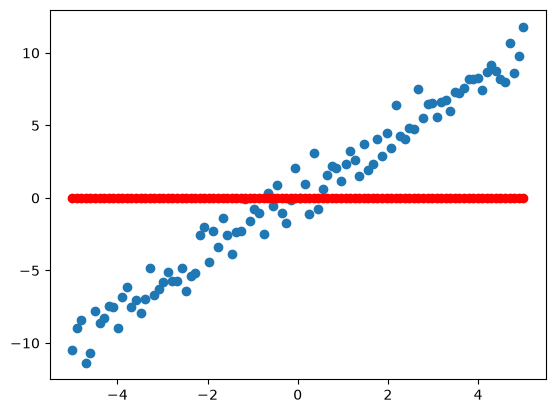

In [3]:
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

y_pred = w * x_data + b
plt.scatter(x_data, y_data)
plt.scatter(x_data, y_pred.detach(), color='red')

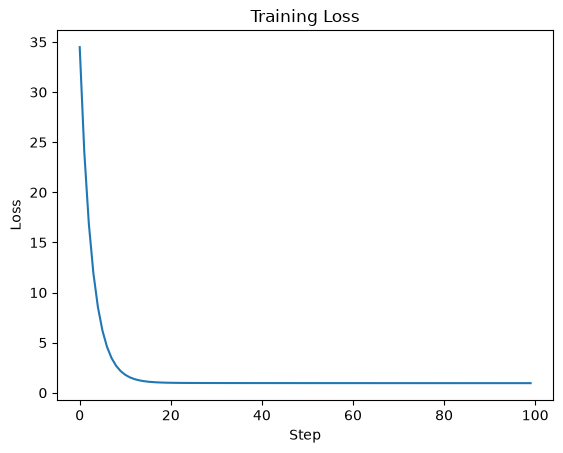

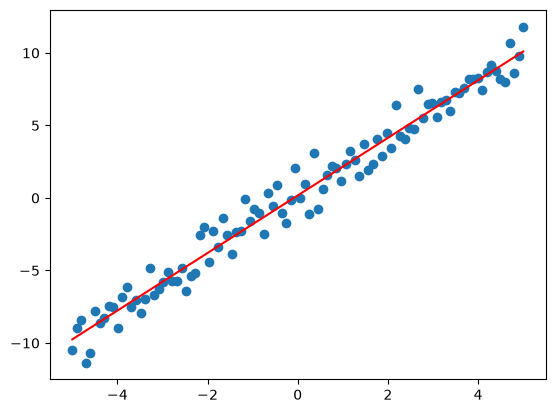

In [4]:
lr = 1e-2
step_n = 100

loss_values = []
for _ in range(step_n):
    y_pred = w * x_data + b

    loss = torch.mean((y_data - y_pred) ** 2)
    loss_values.append(loss.item())
    loss.backward()

    w.data -= lr * w.grad
    b.data -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()  

plt.plot(loss_values)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

plt.scatter(x_data, y_data)
plt.plot(x_data, y_pred.detach(), color='red')